In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import metrics

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/multiclassificationtask/sample_submission.csv
/kaggle/input/multiclassificationtask/train.csv
/kaggle/input/multiclassificationtask/test.csv


In [108]:
df = pd.read_csv('/kaggle/input/multiclassificationtask/train.csv')

df = df.drop(['id'],axis=1)

df = df[df['Status'] != 'Y']

x = df.drop('Status', axis=1)
y = df['Status']

df.head()

,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,2178.0,D-penicillamine,16374.0,F,N,N,N,N,0.5,263.0,3.20,43.0,1110.0,106.95,67.0,430.0,9.6,3.0,C
1,2644.0,D-penicillamine,17774.0,F,N,N,N,N,0.8,280.0,3.60,22.0,678.0,62.00,80.0,427.0,13.0,3.0,C
2,3069.0,Placebo,17844.0,F,N,N,N,N,1.1,408.0,4.40,54.0,2108.0,142.60,137.0,203.0,10.6,3.0,C
3,2216.0,Placebo,19221.0,F,N,Y,Y,N,0.8,252.0,3.70,36.0,843.0,55.80,56.0,336.0,9.6,4.0,C
4,2256.0,Placebo,21600.0,F,N,N,N,N,4.7,348.0,3.06,464.0,961.0,120.90,146.0,298.0,11.0,2.0,D


In [109]:
l_en = LabelEncoder()
y = l_en.fit_transform(y)

In [110]:
cat = x.select_dtypes(include=['object']).columns.to_list()
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', OneHotEncoder(handle_unknown='ignore'))
])

num = x.select_dtypes(include=['float64']).columns.to_list()
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

proc = ColumnTransformer([
    ('categorical', cat_pipeline, cat),
    ('numerical', num_pipeline, num)
])

x_prepared = proc.fit_transform(x)


x_train, x_test, y_train, y_test = train_test_split(x_prepared, y, test_size=0.2, random_state=42)

              precision    recall  f1-score   support

           0       0.84      0.93      0.88      2004
           1       0.17      0.01      0.03        74
           2       0.81      0.67      0.73       922

    accuracy                           0.83      3000
   macro avg       0.60      0.54      0.55      3000
weighted avg       0.81      0.83      0.81      3000

Model aniqligi: 0.8286666666666667
Log Loss: 0.46703083328913747


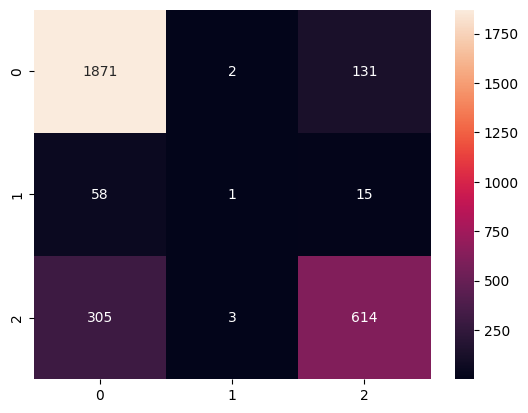

In [111]:
# Train model
lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(x_train, y_train)

# Prediction
y_pred = lr_model.predict(x_test)
y_proba = lr_model.predict_proba(x_test)

# Classification report
lr_model_report = metrics.classification_report(y_test, y_pred, zero_division=0)
lr_model_accuracy = metrics.accuracy_score(y_test, y_pred)
print(lr_model_report)
print("Model aniqligi:", lr_model_accuracy)

# Log Loss
print("Log Loss:", metrics.log_loss(y_test, y_proba, labels=[0, 1, 2]))

# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

In [112]:
# Train model
svm = SVC()
svm.fit(x_train, y_train)

# Prediction
y_pred = svm.predict(x_test)
y_proba = svm.predict_proba(x_test)

# Classification report
svm_report = metrics.classification_report(y_test, y_pred, zero_division=0)
svm_accuracy = metrics.accuracy_score(y_test, y_pred)
print(svm_report)
print("Model aniqligi:", svm_accuracy)

# Log Loss
print("Log Loss:", metrics.log_loss(y_test, y_proba, labels=[0, 1, 2]))


# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

AttributeError: predict_proba is not available when  probability=False

In [ ]:
# Train model
tree = DecisionTreeClassifier()
tree.fit(x_train, y_train)

# Prediction
y_pred = tree.predict(x_test)
y_proba = tree.predict_proba(x_test)

# Classification report
tree_report = metrics.classification_report(y_test, y_pred, zero_division=0)
tree_accuracy = metrics.accuracy_score(y_test, y_pred)
print(tree_report)
print("Model aniqligi:", tree_accuracy)

# Log Loss
print("Log Loss:", metrics.log_loss(y_test, y_proba, labels=[0, 1, 2]))


# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

In [ ]:
# Train model
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)

# Prediction
y_pred = rf_model.predict(x_test)
y_proba = rf_model.predict_proba(x_test)

# Classification report
rf_model_report = metrics.classification_report(y_test, y_pred, zero_division=0)
rf_model_accuracy = metrics.accuracy_score(y_test, y_pred)
print(rf_model_report)
print("Model aniqligi:", rf_model_accuracy)

# Log Loss
print("Log Loss:", metrics.log_loss(y_test, y_proba, labels=[0, 1, 2]))


# Consufion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="g")
plt.show()

In [ ]:
# Report

# Linear Regression
print("Linear Regression results")
print(lr_model_report)
print("Model aniqliligi:",lr_model_accuracy)

# SVM
print("Support Vector Machine results")
print(svm_report)
print("Model aniqliligi:", svm_accuracy)

# Decision Tree
print("Decision Tree results")
print(tree_report)
print("Model aniqliligi:", tree_accuracy)

# Rain Forest
print("Rain Forest results")
print(rf_model_report)
print("Model aniqliligi:", rf_model_accuracy)

In [ ]:
df_test = pd.read_csv('/kaggle/input/multiclassificationtask/test.csv')

ids = df_test['id']
sub = df_test.drop('id', axis = 1)
df_test_prepared = proc.transform(sub)

y_probs = rf_model.predict_proba(df_test_prepared)

# Ehtimolliklarni cheklash
y_probs = np.clip(y_probs, 1e-15, 1 - 1e-15)

encoded_classes = l_en.classes_
# Natijalar quyidagicha tartibda saqlanadi - array(['C', 'CL', 'D'], dtype=object)

In [ ]:
submission_df = pd.DataFrame({'id': ids})

In [ ]:
desired_columns_map = {
    'C': 'Status_C',
    'CL': 'Status_CL',
    'D': 'Status_D'
}

In [ ]:
if y_probs.shape[1] != len(encoded_classes):
    print("Xatolik: Ehtimolliklar ustunlari soni klasslar soniga mos kelmayapti!")
else:
    for i, class_label in enumerate(encoded_classes):
        # class_label bu 'C', 'CL', 'D' kabi qiymat
        # Agar 'Status C' kabi aniq nomlar kerak bo'lsa va class_label ('C', 'CL', 'D') shularga mos kelsa:
        if class_label in desired_columns_map:
            column_name = desired_columns_map[class_label]
            submission_df[column_name] = y_probs[:, i]
        else:
            # Agar l_en.classes_ da kutilmagan qiymat bo'lsa, umumiy nom beramiz
            # Yoki xatolik haqida xabar berish mumkin
            print(f"Ogohlantirish: '{class_label}' uchun maxsus ustun nomi topilmadi. 'Status_{class_label}' ishlatiladi.")
            submission_df[f'Status_{class_label}'] = y_probs[:, i]

In [ ]:
submission_filename = 'submission_probabilities.csv'
submission_df.to_csv(submission_filename, index=False)

In [ ]:
print(f"\nNatijalar '{submission_filename}' fayliga saqlandi.")
print(submission_df.head())